# TIME SERIES - KIỂM ĐỊNH TÍNH DỪNG (STATIONARITY TESTING)

# Mục lục
1. [Mục tiêu](#sec-1)
2. [Tính Dừng và các Phương pháp Kiểm định](#sec-2)
    - [2.1. Chuỗi dừng (Stationary) và Chuỗi không dừng (Non-stationary)](#sec-2-1)
    - [2.2. Tại sao phải kiểm định tính dừng trước khi mô hình hóa?](#sec-2-2)
    - [2.3. Các phương pháp kiểm định](#sec-2-3)
        - [ADF Test — Augmented Dickey-Fuller](#sec-2-3-1)
        - [KPSS Test — Kwiatkowski–Phillips–Schmidt–Shin](#sec-2-3-2)
        - [PP Test — Phillips-Perron](#sec-2-3-3)
    - [2.4. Bảng so sánh 3 Kiểm định](#sec-2-4)
3. [Phương pháp Khử Tính Không Dừng](#sec-3)
    - [3.1. Sai phân (Differencing) — Loại bỏ xu hướng (Trend)](#sec-3-1)
    - [3.2. Ổn định Phương sai (Variance Stabilization)](#sec-3-2)
    - [3.3. Bảng tổng quan các phương pháp](#sec-3-3)
4. [Nạp dữ liệu](#sec-4)
5. [Thực nghiệm Kiểm định Tính Dừng — Chuỗi Gốc](#sec-5)
6. [Thực nghiệm Biến đổi và Kiểm định lại](#sec-6)
7. [Phân tích và Nhận xét Kết quả Thực nghiệm](#sec-7)
    - [7.1. Chuỗi số ca mắc COVID gốc có tính dừng không? Ý nghĩa thực tế là gì?](#sec-7-1)
    - [7.2. Biến đổi Log có giúp ổn định phương sai không?](#sec-7-2)
    - [7.3. Box-Cox có cải thiện tính dừng tốt hơn Log không?](#sec-7-3)
    - [7.4. Sai phân bậc 1 có đủ để làm chuỗi dừng không?](#sec-7-4)
    - [7.5. Phương pháp biến đổi nào là tốt nhất? Chuỗi cần sai phân bao nhiêu lần (d=?)?](#sec-7-5)
8. [Kết luận](#sec-8)

In [4]:
import os
import sys
import warnings

for src_path in (os.path.abspath("../src"), os.path.abspath("src")):
    if os.path.isdir(src_path) and src_path not in sys.path:
        sys.path.append(src_path)

warnings.filterwarnings("ignore")

from time_series.dataset import TimeSeriesDataset
from time_series.preprocessing_non_stationarity import ADFTesting, KPSSTesting, PPTesting, StationarityTransformer
from visualization.comparison import plot_rolling_statistics

<a id="sec-1"></a>

# 1. Mục tiêu
# KIỂM ĐỊNH TÍNH DỪNG (STATIONARITY TESTING)

## 1. Mục tiêu
* Xác định liệu chuỗi thời gian số ca mắc COVID-19 mới hằng ngày có đạt **tính dừng (stationarity)** hay không, từ đó lựa chọn kỹ thuật tiền xử lý phù hợp trước khi đưa dữ liệu vào các mô hình.
* Chuỗi dữ liệu COVID-19 có phải chuỗi dừng không? Nếu không, phương pháp biến đổi nào là tối ưu nhất để chuyển chuỗi về trạng thái dừng? Cần sai phân bao nhiêu lần?
* **Tại sao phải kiểm định tính dừng?** Đa số các mô hình dự báo chuỗi thời gian chỉ hoạt động chính xác trên **chuỗi dừng**. Nếu đưa chuỗi không dừng vào mô hình, kết quả dự đoán sẽ sai lệch.

## 2. Tính Dừng và các Phương pháp Kiểm định

### 2.1. Chuỗi dừng (Stationary) và Chuỗi không dừng (Non-stationary)

- **Chuỗi dừng (Stationary):** Là chuỗi thời gian có các thuộc tính thống kê (như trung bình - mean, phương sai - variance) luôn **không đổi** theo thời gian.

<figure style="text-align: center;">
  <img src="./assets/Stationary-Time-Series.png" alt="RGB image">
  <figcaption>Stationary Time Series</figcaption>
</figure>

- **Chuỗi không dừng (Non-stationary):** Là chuỗi thời gian có các thuộc tính thống kê (mean, variance) **thay đổi** theo thời gian. Bất kỳ chuỗi nào có trend hoặc seasonality đều là chuỗi không dừng. Lý do là vì trend/seasonality làm cho giá trị trung bình và phương sai bị thay đổi tại các thời điểm khác nhau.

<figure style="text-align: center;">
  <img src="./assets/Non-Stationary-Time-Series.png" alt="RGB image">
  <figcaption>Non-Stationary Time Series</figcaption>
</figure>

| Tiêu chí | Chuỗi Dừng (Stationary) | Chuỗi Không Dừng (Non-Stationary) |
| :--- | :---: | :--- |
| **Sự phụ thuộc thời gian** | Thuộc tính thống kê độc lập với thời điểm quan sát | Thuộc tính thống kê là một hàm số phụ thuộc vào thời gian quan sát |
| **Tham số (trung bình, phương sai,...)** | Không đổi | Thay đổi |
| **Yếu tố nhiễu** | Không có xu hướng (trend) hay seasonality | Có trend hoặc seasonality |

### 2.2. Tại sao phải kiểm định tính dừng trước khi mô hình hóa?

- **Dự báo từ chuỗi không dừng sẽ sai lệch:** Nếu một quá trình không dừng, các thuộc tính của nó (trung bình, phương sai) sẽ liên tục thay đổi. Việc ước lượng chúng bằng cách lấy trung bình theo thời gian sẽ không chính xác, dẫn đến kết quả dự báo sai lệch và gây hiểu lầm.
- **Đảm bảo độ tin cậy của kết luận:** Dữ liệu dừng dễ phân tích hơn và các suy luận rút ra từ nó có độ tin cậy cao hơn.
- **Giả định bắt buộc của các mô hình:** Nhiều quy trình thống kê trong phân tích chuỗi thời gian yêu cầu dữ liệu phải là chuỗi dừng. Hầu hết các phương pháp dự báo đều dựa trên giả định: "Các đặc điểm thống kê của dữ liệu trong tương lai sẽ tiếp tục duy trì giống như trong quá khứ" → Điều này chỉ đúng nếu chuỗi đó là chuỗi dừng.

### 2.3. Các phương pháp kiểm định

**Unit Root:** là một đặc điểm của time series khiến nó **không có tính dừng**. Một chuỗi được coi là có Unit Root nếu giá trị của $\alpha = 1$ trong phương trình:

$$Y_t = \alpha Y_{t-1} + \beta X_e + \epsilon$$

Trong đó: $Y_t$ là giá trị tại thời điểm $t$, và $X_e$ là một exogenous variable

Khi $\alpha = 1$, giá trị hiện tại phụ thuộc hoàn toàn vào giá trị trước đó cộng với các yếu tố bên ngoài, khiến chuỗi thay đổi đặc tính thống kê (mean, variance) theo thời gian.


#### ADF Test — Augmented Dickey-Fuller

**ADF** sử dụng mô hình hồi quy để kiểm định sự tồn tại của Unit Root.

$$\Delta Y_t = c + \beta t + \gamma Y_{t-1} + \sum_{i=1}^p \phi_i \Delta Y_{t-i} + \epsilon_t$$

Trong đó:
- $\Delta Y_t = Y_t - Y_{t-1}$
- $\gamma = \alpha - 1$: hệ số kiểm định, dùng để kiểm định sự tồn tại của Unit Root

Mục tiêu của kiểm định là kiểm tra xem hệ số $\gamma$ có bằng 0 hay không.

- **Giả thuyết:** $H_0$: Chuỗi không dừng hay có Unit Root ($\gamma = 0$) | $H_1$: Chuỗi dừng.
- **Tiêu chí kết luận:**
  - Nếu $p\text{-value} \le 0.05$ → Bác bỏ $H_0$ → Chuỗi dừng.
  - Nếu $p\text{-value} > 0.05$ → không bác bỏ $H_0$ → Chuỗi không dừng.

#### KPSS Test — Kwiatkowski–Phillips–Schmidt–Shin
KPSS là một kiểm định phổ biến được sử dụng để đánh giá tính dừng của chuỗi thời gian. Điểm quan trọng là giả thuyết của KPSS hoàn toàn trái ngược với ADF, do đó hai kiểm định này không thể sử dụng thay thế cho nhau mà thường được dùng kết hợp để kiểm chứng chéo.

- **Giả thuyết:** $H_0$: Chuỗi dừng | $H_1$: Chuỗi không dừng.

- **Tiêu chí Kết luận:**
  - Nếu $p\text{-value} \le 0.05$  → bác bỏ $H_0$ → Chuỗi không dừng.
  - Nếu $p\text{-value} > 0.05$ → không bác bỏ $H_0$ → Chuỗi dừng.

#### PP Test — Phillips-Perron
- **Cơ chế:** Tương tự ADF nhưng sử dụng điều chỉnh phi tham số  để xử lý tự tương quan (autocorrelation) và phương sai thay đổi trong phần dư (residuals), thay vì đưa trực tiếp các độ trễ vào mô hình hồi quy.
- **Giả thuyết:** $H_0$: Chuỗi có Unit Root (không dừng) | $H_1$: Chuỗi dừng.
- **Tiêu chí Kết luận:**
  - Nếu $p\text{-value} \le 0.05$  → bác bỏ $H_0$ → Chuỗi dừng.
  - Nếu $p\text{-value} > 0.05$ → không bác bỏ $H_0$ → Chuỗi không dừng.


### 2.4. Bảng so sánh 3 Kiểm định

| Tiêu chí | ADF Test | KPSS Test | PP Test |
| :--- | :--- | :--- | :--- |
| **Mục tiêu** | Tìm Unit Root | Kiểm định tính dừng | Kiểm định Unit Root và hiệu chỉnh phương sai thay đổi |
| **Giả thuyết $H_0$** | Không dừng (có Unit Root) | Dừng (Không có Unit Root) | Không dừng (có Unit Root) |
| **Xử lý autocorrelation** | Thêm các biến trễ (lags) vào phương trình hồi quy | Phụ thuộc vào việc ước lượng phương sai của phần dư | Điều chỉnh phi tham số |
| **Điểm mạnh** | Dễ giải thích | Giả thuyết ngược với ADF, dùng dể kiểm chứng chéo cho ADF | Ổn định khi phương sai thay đổi |
| **Điểm yếu** | Kết quả nhạy cảm với việc chọn biến trễ (lags) | Có thể cho kết luận sai khi xu hướng quá mạnh | Hiêu suất thấp đối với các chuỗi có kích thước mẫu nhỏ |

**Có nên dùng cả 3 kiểm định?**

Thông thường, chỉ cần **ADF** hoặc **KPSS** hay tốt hơn là kết hợp **ADF + KPSS** là đủ để kết luận:
- Nếu cả ADF (bác bỏ $H_0$) và KPSS (không bác bỏ $H_0$) đều kết luận **dừng** → Kết luận chắc chắn chuỗi dừng.
- Nếu cả hai đều kết luận **không dừng** → Kết luận chắc chắn chuỗi không dừng.
- Nếu hai kiểm định **mâu thuẫn** nhau → Chuỗi có thể là *trend-stationary*, khi đó cần phân tích thêm.

## 3. Phương pháp Khử Tính Không Dừng

### 3.1. Sai phân (Differencing) — Loại bỏ xu hướng (Trend)

Sai phân loại bỏ thành phần xu hướng bằng cách tính **sự thay đổi** thay vì giá trị tuyệt đối:

- **Sai phân bậc 1 (d=1):** $Y'_t = Y_t - Y_{t-1}$
  - Ý nghĩa: $Y'_t$ phản ánh **tốc độ thay đổi số ca mắc mới** (hôm nay tăng/giảm bao nhiêu so với hôm qua).
  - Loại bỏ xu hướng **tuyến tính**.
  
- **Sai phân bậc 2 (d=2):** $Y''_t = Y'_t - Y'_{t-1} = (Y_t - Y_{t-1}) - (Y_{t-1} - Y_{t-2})$
  - Loại bỏ xu hướng **phi tuyến**.

### 3.2. Ổn định Phương sai (Variance Stabilization)

- **Logarithm:** $Y'_t = \ln(Y_t + c)$ (với $c$ là hằng số để tránh $\ln(0)$)
  - Thu hẹp khoảng cách giữa các giá trị lớn (như ngày xuất hiện nhiều ca dịch) và những ngày ít người mắc dịch, từ đó giúp phương sai đồng đều hơn.
  - **Không** loại bỏ được xu hướng nếu trend mạnh.
  
- **Box-Cox:** $Y'_t = \dfrac{Y_t^\lambda - 1}{\lambda}$ (với $\lambda \neq 0$; nếu $\lambda = 0$ thì trở về Logarithm)
  - Tự động tìm tham số $\lambda$ tối ưu để đưa phân phối của chuỗi về gần với phân phối chuẩn nhất.

### 3.3. Bảng tổng quan các phương pháp

| Phương pháp | Biểu thức | Xử lý vấn đề gì? | Khi nào dùng? | Độ phức tạp |
| :--- | :---: | :--- | :--- | :--- |
| **Sai phân bậc 1** | $Y_t - Y_{t-1}$ | Trung bình thay đổi tuyến tính | Trend đơn giản | $O(N)$ |
| **Sai phân bậc 2** | $Y'_t - Y'_{t-1}$ | Trung bình thay đổi phi tuyến | Trend cong | $O(N)$ |
| **Logarithm** | $\ln(Y_t + c)$ | Phương sai tăng theo cấp số nhân | Dữ liệu tăng trưởng theo hàm mũ | $O(N)$ |
| **Box-Cox** | $\frac{Y_t^\lambda - 1}{\lambda}$ | Phương sai không ổn định, phân phối lệch | Chuỗi phân phối lệch | $O(N \log N)$ |

## 4. Nạp dữ liệu

In [5]:
DATA_PATH = "../data/time_series/time-series-19-covid-combined.csv"
TIME_COLUMN = "Date"
TARGET_COLUMN = "New_Cases"

dataset = TimeSeriesDataset(path=DATA_PATH, time_column=TIME_COLUMN)

df_raw = dataset.data
df_grouped = df_raw.groupby(TIME_COLUMN)[["Confirmed", "Recovered", "Deaths"]].sum().reset_index()

df_grouped["New_Cases"] = df_grouped["Confirmed"].diff().fillna(0).clip(lower=0)
df_grouped["New_Recovered"] = df_grouped["Recovered"].diff().fillna(0).clip(lower=0)
df_grouped["New_Deaths"] = df_grouped["Deaths"].diff().fillna(0).clip(lower=0)

dataset.data = df_grouped
print(f"Shape: {dataset.data.shape}")
print(f"Khoảng thời gian: {df_grouped[TIME_COLUMN].min().date()} -> {df_grouped[TIME_COLUMN].max().date()}")

[Time Series Mode] Đã nạp và sắp xếp dữ liệu theo 'Date'.
Shape: (270, 7)
Khoảng thời gian: 2020-01-22 -> 2020-10-17


## 5. Thực nghiệm Kiểm định Tính Dừng — Chuỗi Gốc

Thực hiện cả 3 kiểm định (ADF, KPSS, PP) trên chuỗi `New_Cases` gốc (số ca COVID mới theo ngày, chưa qua biến đổi) với mức ý nghĩa $\alpha = 0.05$.

In [6]:
print(f"--- KIEM DINH TINH DUNG CHUOI GOC: {TARGET_COLUMN} ---")

dataset.accept(ADFTesting(column_name=TARGET_COLUMN))
dataset.accept(KPSSTesting(column_name=TARGET_COLUMN))
dataset.accept(PPTesting(column_name=TARGET_COLUMN))

--- KIEM DINH TINH DUNG CHUOI GOC: New_Cases ---
Bước xử lý  : Augmented Dickey-Fuller (ADF) Test
Thuộc tính  : New_Cases
p-value     : 0.979917
Kết luận    : KHÔNG DỪNG (Non-Stationary)
--------------------------------------------------
Bước xử lý  : KPSS Test
Thuộc tính  : New_Cases
p-value     : 0.010000
Kết luận    : KHÔNG DỪNG (Non-Stationary)
--------------------------------------------------
Bước xử lý  : Phillips-Perron (PP) Test
Thuộc tính  : New_Cases
p-value     : 0.707415
Kết luận    : KHÔNG DỪNG (Non-Stationary)
--------------------------------------------------


### 5.1. Trực quan hóa Rolling Statistics — Chuỗi Gốc `New_Cases`

Trước khi bước vào biến đổi, quan sát **Rolling Mean** và **Rolling STD** để trực quan tính không dừng của dữ liệu:
- **Rolling Mean không phẳng** → trung bình thay đổi theo thời gian
- **Rolling STD dao động mạnh** → phương sai không ổn định

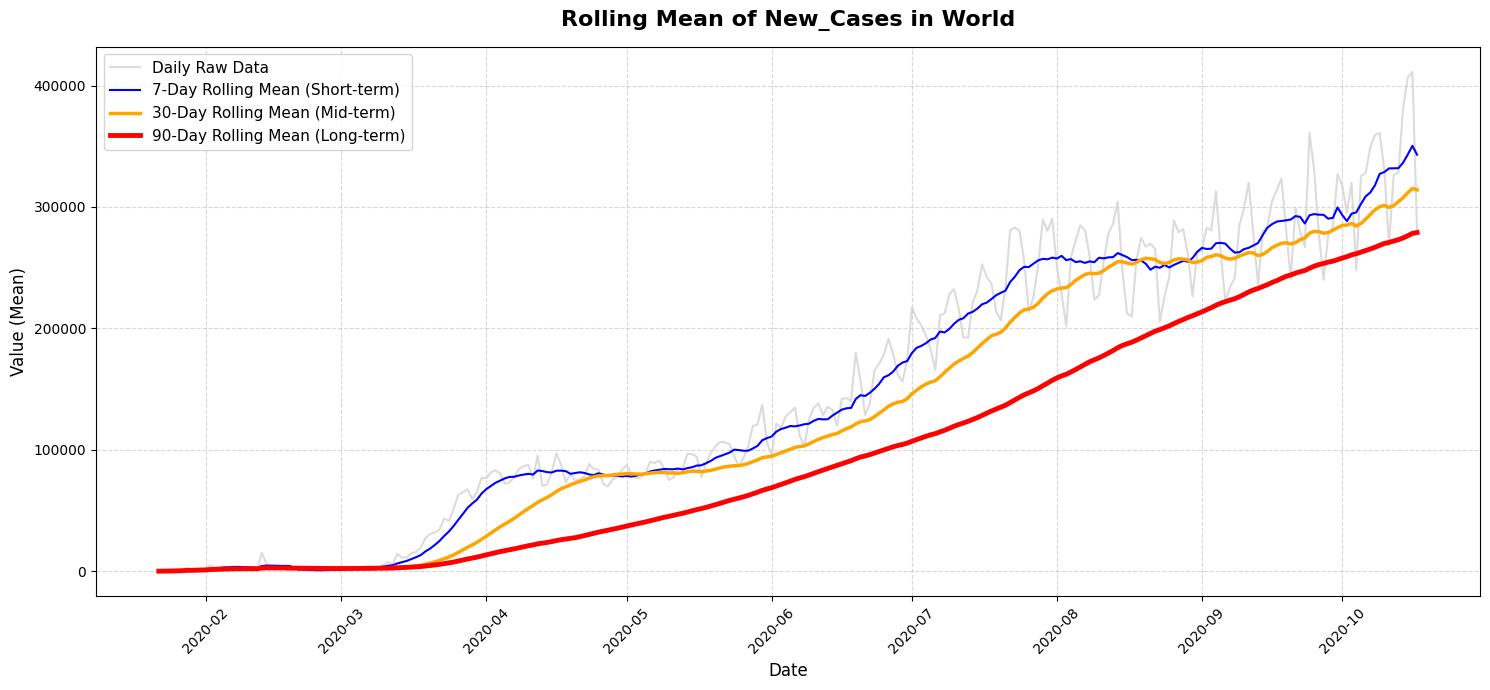

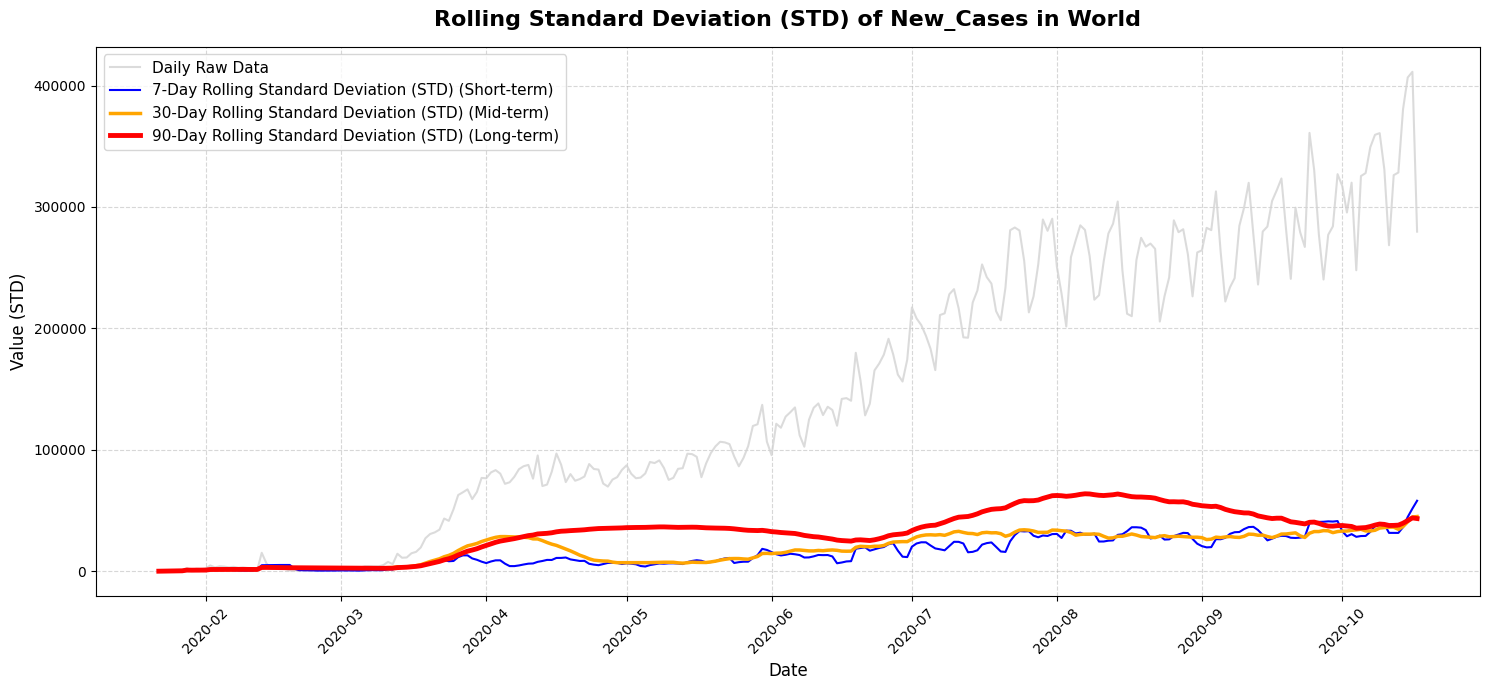

In [7]:
# Rolling Mean — quan sát xu hướng thay đổi theo thời gian
plot_rolling_statistics(
    dates=df_grouped[TIME_COLUMN],
    values=df_grouped[TARGET_COLUMN],
    feature_name=TARGET_COLUMN,
    stat_type="Mean",
    region="World"
)

# Rolling STD — quan sát phương sai thay đổi theo thời gian
plot_rolling_statistics(
    dates=df_grouped[TIME_COLUMN],
    values=df_grouped[TARGET_COLUMN],
    feature_name=TARGET_COLUMN,
    stat_type="STD",
    region="World"
)

## 6. Thực nghiệm Biến đổi và Kiểm định lại

Áp dụng lần lượt 4 phương pháp biến đổi (`log`, `boxcox`, `diff_1`, `diff_2`) lên chuỗi `New_Cases` và chạy lại kiểm định ADF trên từng chuỗi đã biến đổi để đánh giá hiệu quả từng phương pháp.

In [8]:
print("--- AP DUNG CAC PHEP BIEN DOI ---")
for method in ['log', 'boxcox', 'diff_1', 'diff_2']:
    dataset.accept(StationarityTransformer(column_name=TARGET_COLUMN, method=method))

print("\n--- KIEM DINH LAI BANG ADF SAU BIEN DOI ---")
transformed_columns = [f"{TARGET_COLUMN}_log", f"{TARGET_COLUMN}_boxcox", 
                       f"{TARGET_COLUMN}_diff_1", f"{TARGET_COLUMN}_diff_2"]

for col in transformed_columns:
    dataset.accept(ADFTesting(column_name=col))

--- AP DUNG CAC PHEP BIEN DOI ---
Bước xử lý : Stationarity Transform (log) | Trạng thái: Success
Bước xử lý : Stationarity Transform (boxcox) | Trạng thái: Success
Bước xử lý : Stationarity Transform (diff_1) | Trạng thái: Success
Bước xử lý : Stationarity Transform (diff_2) | Trạng thái: Success

--- KIEM DINH LAI BANG ADF SAU BIEN DOI ---
Bước xử lý  : Augmented Dickey-Fuller (ADF) Test
Thuộc tính  : New_Cases_log
p-value     : 0.408032
Kết luận    : KHÔNG DỪNG (Non-Stationary)
--------------------------------------------------
Bước xử lý  : Augmented Dickey-Fuller (ADF) Test
Thuộc tính  : New_Cases_boxcox
p-value     : 0.710192
Kết luận    : KHÔNG DỪNG (Non-Stationary)
--------------------------------------------------
Bước xử lý  : Augmented Dickey-Fuller (ADF) Test
Thuộc tính  : New_Cases_diff_1
p-value     : 0.007507
Kết luận    : DỪNG (Stationary)
--------------------------------------------------
Bước xử lý  : Augmented Dickey-Fuller (ADF) Test
Thuộc tính  : New_Cases_diff_2
p

### 6.1. So sánh Before/After Differencing — `New_Cases` vs `New_Cases_diff_1`

Trực quan hóa hiệu quả của sai phân bậc 1: chuỗi gốc có xu hướng rõ ràng (non-stationary) vs chuỗi sau sai phân dao động quanh 0 (stationary).

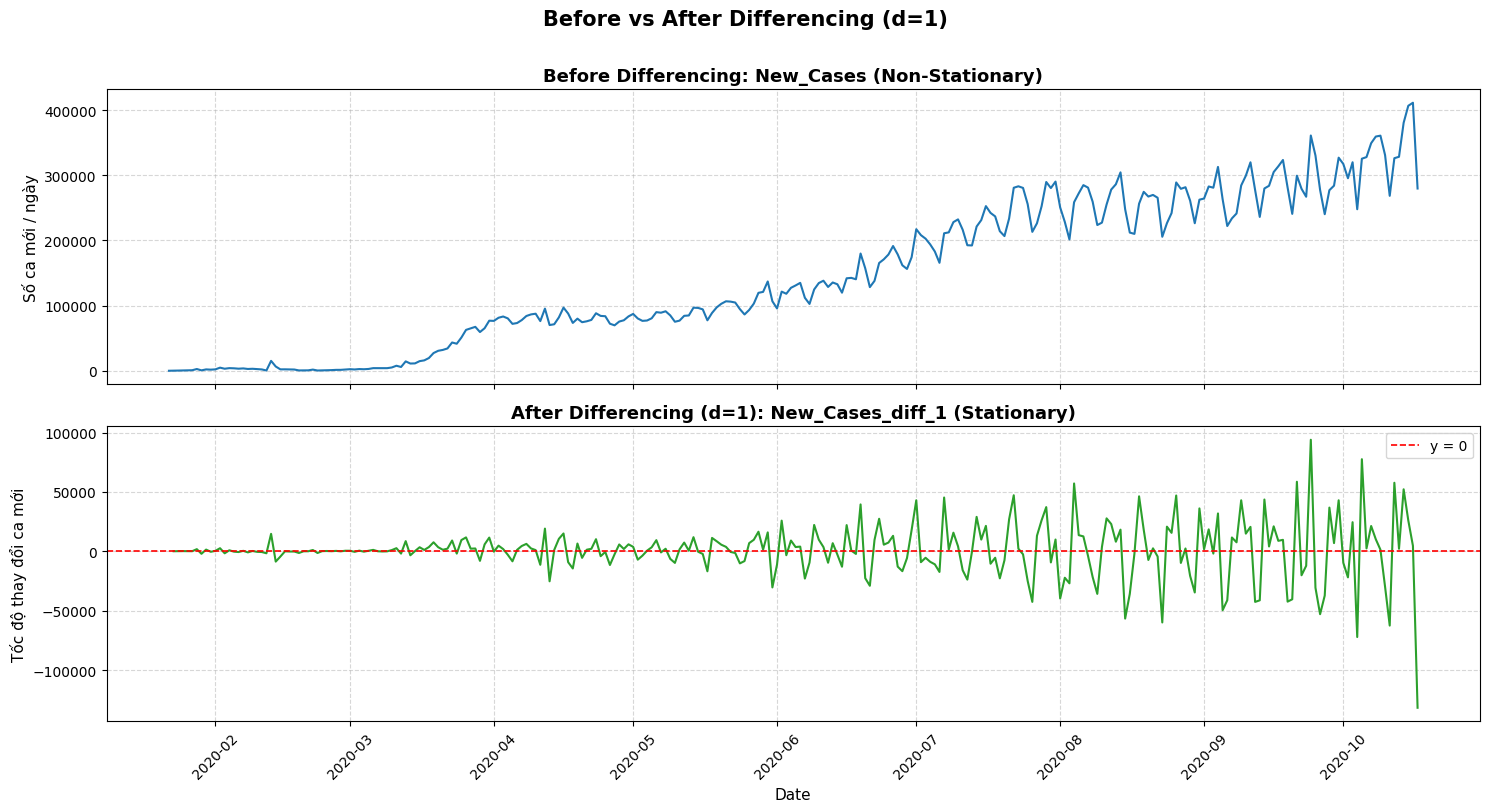

In [9]:
import matplotlib.pyplot as plt

# Lấy DataFrame đã được transform từ dataset (không dùng df_grouped)
df_transformed = dataset.data

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Subplot 1: Chuỗi gốc
axes[0].plot(df_transformed[TIME_COLUMN], df_transformed[TARGET_COLUMN],
             color='#1f77b4', linewidth=1.5)
axes[0].set_title("Before Differencing: New_Cases (Non-Stationary)",
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Số ca mới / ngày", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Sau sai phân bậc 1
axes[1].plot(df_transformed[TIME_COLUMN], df_transformed[f"{TARGET_COLUMN}_diff_1"],
             color='#2ca02c', linewidth=1.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.2, label='y = 0')
axes[1].set_title("After Differencing (d=1): New_Cases_diff_1 (Stationary)",
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel("Tốc độ thay đổi ca mới", fontsize=11)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Before vs After Differencing (d=1)", fontsize=15, fontweight='bold', y=1.01)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Phân tích và Nhận xét Kết quả Thực nghiệm

### 7.1. Chuỗi số ca mắc COVID gốc có tính dừng không? Ý nghĩa thực tế là gì?

**Kết quả kiểm định chuỗi gốc `New_Cases`:**

| Kiểm định | p-value | Kết luận |
| :--- | :---: | :--- |
| ADF | ~0.98 | **KHÔNG DỪNG** |
| KPSS | ~0.01 | **KHÔNG DỪNG** |
| PP | ~0.71 | **KHÔNG DỪNG** |

**Kết luận:** Cả 3 kiểm định đều cho kết quả nhận định rằng chuỗi `New_Cases` là chuỗi **không dừng**.

**Ý nghĩa:**

Kết quả này hoàn toàn phù hợp với tình hình của đại dịch COVID-19. Sự không dừng phản ánh trực tiếp nguyên nhân **nhiều làn sóng lây nhiễm** của dịch bệnh:
- Mỗi biến chủng mới (Alpha, Delta, Omicron,...) tạo ra một đợt bùng phát với quy mô và tốc độ lây lan khác nhau.
- Giữa các làn sóng, khi có giãn cách xã hội hoặc tiêm chủng, số ca mắc lại giảm về mức thấp.
- Điều này làm cho trung bình (mean) của chuỗi liên tục thay đổi — không tồn tại một giá trị trung bình cố định nào đại diện cho toàn bộ chuỗi.

**Hệ quả:** Không thể đưa trực tiếp chuỗi `New_Cases` gốc vào mô hình. Cần tiền xử lý để đạt tính dừng trước.

### 7.2. Biến đổi Log có giúp ổn định phương sai không?

| Chuỗi | p-value ADF | Kết luận |
| :--- | :---: | :--- |
| `New_Cases_log` | ~0.41 | **KHÔNG DỪNG** |

**Nhận xét:** Log transformation **có** giúp ổn định phương sai (thu hẹp khoảng cách giữa đỉnh dịch và đáy dịch), **nhưng không đủ** để đưa chuỗi về trạng thái dừng.

**Giải thích:** Phép biến đổi logarithm chỉ xử lý vấn đề **phương sai thay đổi** — nén các giá trị lớn lại, giảm biên độ dao động. Tuy nhiên, phép biến đổi này **không loại bỏ được xu hướng (trend)** — bản chất là các làn sóng lây nhiễm lên xuống theo thời gian. Chuỗi sau khi logarit hóa vẫn có Mean thay đổi theo thời gian, chỉ là biên độ dao động được thu hẹp lại. Vì vậy p-value ADF vẫn rất cao (~0.41), không bác bỏ được giả thuyết Unit Root.

### 7.3. Box-Cox có cải thiện tính dừng tốt hơn Log không?

| Chuỗi | p-value ADF | Kết luận |
| :--- | :---: | :--- |
| `New_Cases_boxcox` | ~0.71 | **KHÔNG DỪNG** |

**Nhận xét:** **Không.** Box-Cox **không cải thiện** tính dừng tốt hơn Log. Trong trường hợp này, Box-Cox thậm chí cho p-value ADF cao hơn Log (~0.71 so với ~0.41).

Cả Log và Box-Cox đều thuộc nhóm **phép biến đổi ổn định phương sai**, chỉ nén các giá trị mà không loại bỏ xu hướng. Với dữ liệu COVID-19 cả hai phép biến đổi này đều không hiệu quả.

### 7.4. Sai phân bậc 1 có đủ để làm chuỗi dừng không?

| Chuỗi | p-value ADF | Kết luận |
| :--- | :---: | :--- |
| `New_Cases_diff_1` | ~0.0075 | **DỪNG** (p < 0.05) |
| `New_Cases_diff_2` | ~0 | **DỪNG** |

**Nhận xét:** **Sai phân bậc 1 là đủ.** Với p-value ~0.0075 < 0.05, ta bác bỏ giả thuyết $H_0$ (Unit Root), kết luận chuỗi sau sai phân bậc 1 **đã đạt tính dừng**.

**Ý nghĩa**
- Sai phân bậc 1 của `New_Cases` không còn hiểu là "số ca mắc mới trong ngày", nó được hiểu là **tốc độ thay đổi số ca mắc mới**: hôm nay tăng/giảm bao nhiêu ca so với hôm qua.
- Khi giá trị này **dao động quanh 0**, dịch bệnh đang trong giai đoạn ổn định.
- Khi giá trị này **đạt đỉnh dương rồi trở về 0**, đó là tín hiệu một làn sóng lây nhiễm đang chạm đỉnh và bắt đầu suy giảm.

**Về sai phân bậc 2:** Sai phân bậc 2 (p-value ≈ 0) cho kết quả dừng chắc chắn hơn. Tuy nhiên, chỉ nên dùng sai phân bậc 2 khi bậc 1 chưa đạt tính dừng.

### 7.5. Phương pháp biến đổi nào là tốt nhất? Chuỗi cần sai phân bao nhiêu lần (d=?)?

**Bảng tổng kết kết quả thực nghiệm:**

| Phương pháp | Chuỗi kết quả | p-value ADF | Đạt dừng? | Nhận xét |
| :--- | :--- | :---: | :---: | :--- |
| Không biến đổi | `New_Cases` | ~0.98 | Không | Xu hướng rõ ràng do các làn sóng dịch |
| Logarithm | `New_Cases_log` | ~0.41 | Không | Ổn định phương sai nhưng không loại bỏ xu hướng |
| Box-Cox | `New_Cases_boxcox` | ~0.71 | Không | Tương tự Logarithm |
| **Sai phân bậc 1** | **`New_Cases_diff_1`** | **~0.0075** | **Có** | **Phương pháp tối ưu, d=1** |
| Sai phân bậc 2 | `New_Cases_diff_2` | ~0 | Có | - |

**Kết luận cuối cùng:** **Sai phân bậc 1 (d=1)** là phương pháp tối ưu nhất để xử lý tính không dừng cho chuỗi COVID-19.

### KẾT LUẬN

Việc kiểm định tính dừng không chỉ là thủ tục học thuật, mà mang lại các giá trị thực tiễn quan trọng:

1. **Tránh sai lầm trong mô hình hóa:** Xác nhận chuỗi "không dừng" giúp tránh đưa dữ liệu thô vào mô hình, gây ra kết quả dự báo sai lệch hoàn toàn.
2. **Xác định tham số mô hình:** Kết quả cho thấy chuỗi COVID-19 cần sai phân **d=1** trước khi đưa vào mô hình.
3. Chuỗi sau sai phân bậc 1 (tốc độ thay đổi ca mắc mới) dao động quanh 0 — cho phép nhận diện thời điểm đỉnh dịch (khi giá trị chuyển từ dương sang âm).